# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

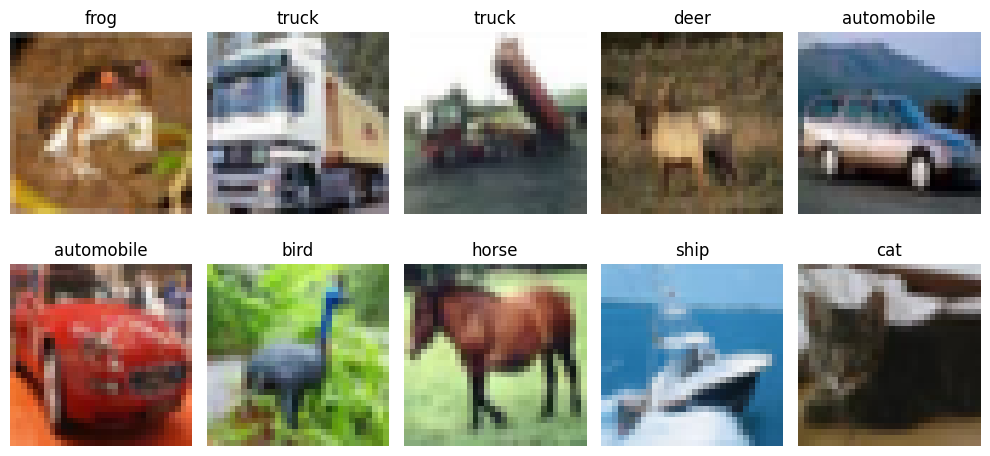

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
# TASK 1: Increase ANN layers

# Added an extra hidden layer (1024 -> 512 -> 256)
# to increase the network's learning capacity.
# This allows the ANN to learn more complex patterns from CIFAR-10 images,although it may increase the risk of overfitting.

ann_model=models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2497 - loss: 2.0333 - val_accuracy: 0.3034 - val_loss: 1.9010
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3044 - loss: 1.8977 - val_accuracy: 0.3440 - val_loss: 1.8464
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3270 - loss: 1.8462 - val_accuracy: 0.3500 - val_loss: 1.7923
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3383 - loss: 1.8149 - val_accuracy: 0.3740 - val_loss: 1.7502
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3519 - loss: 1.7877 - val_accuracy: 0.3724 - val_loss: 1.7443
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3607 - loss: 1.7608 - val_accuracy: 0.4002 - val_loss: 1.7220
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3635 - loss: 1.7558 - val_accuracy: 0.4128 - val_loss: 1.6734
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3745 - loss: 1.7291 - val_accuracy: 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4329 - loss: 1.6256
ANN Test Accuracy: 0.43290001153945923


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
# TASK 2: Increase CNN filters

# Increased convolution filters from
# 32 -> 64 -> 128.
# More filters help the model learn richer and more detailed image features at deeper layers.

cnn_model=models.Sequential([
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TASK 3: Increase training epochs

# Increased training duration from 10 epochs -> 20 epochs 
# so the model has more opportunities to learn from the training data.

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,  # change the epochs to 20
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.3986 - loss: 1.6469 - val_accuracy: 0.4580 - val_loss: 1.6077
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.5521 - loss: 1.2491 - val_accuracy: 0.6478 - val_loss: 0.9806
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.6216 - loss: 1.0626 - val_accuracy: 0.6738 - val_loss: 0.9470
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.6738 - loss: 0.9300 - val_accuracy: 0.7014 - val_loss: 0.8522
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7150 - loss: 0.8268 - val_accuracy: 0.7150 - val_loss: 0.8315
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7465 - loss: 0.7361 - val_accuracy: 0.7578 - val_loss: 0.7061
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7744 - loss: 0.6535 - val_accuracy: 0.7734 - val_loss: 0.6745
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.8004 - loss: 0.5702 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8037 - loss: 0.8557
CNN Test Accuracy: 0.8036999702453613


In [9]:
# TASK 4: Early Stopping

# Stops training automatically when validation loss stops improving for several epochs.
# Best weights are restored to prevent overfitting.

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [10]:
cnn_history=cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.9494 - loss: 0.1450 - val_accuracy: 0.8010 - val_loss: 1.0008
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9543 - loss: 0.1349 - val_accuracy: 0.8118 - val_loss: 0.9215
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9577 - loss: 0.1264 - val_accuracy: 0.8134 - val_loss: 0.8675
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9574 - loss: 0.1283 - val_accuracy: 0.8136 - val_loss: 0.8921
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9578 - loss: 0.1223 - val_accuracy: 0.8038 - val_loss: 0.9600
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9634 - loss: 0.1066 - val_accuracy: 0.8204 - val_loss: 0.8752
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9622 - loss: 0.1116 - val_accuracy: 0.8216 - val_loss: 0.9754
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.9673 - loss: 0.0967 - 

## 📈 Compare Learning Curves

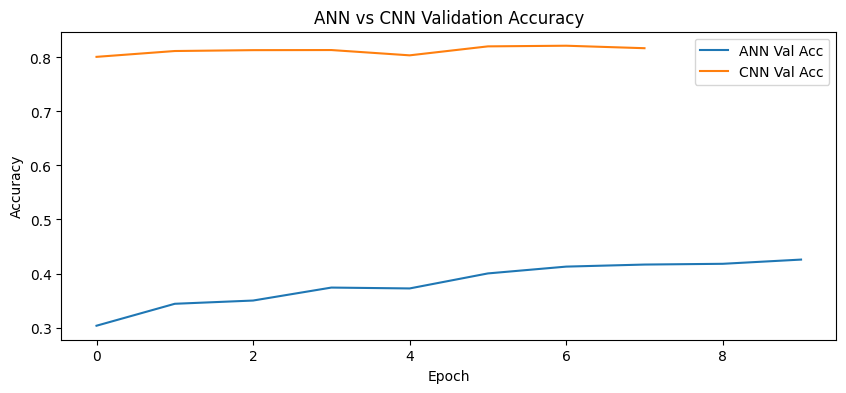

In [11]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [19]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

early_stop_aug=EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


In [21]:
# TASK 5: Data Augmentation

# Applied RandomFlip, RandomRotation, and RandomZoom
# to generate new image variations during training.
# This improves model generalization.

aug_model = models.Sequential([data_augmentation,
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

aug_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history=aug_model.fit(x_train_norm,y_train,epochs=20,validation_split=0.1,callbacks=[early_stop_aug],batch_size=64)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.3999 - loss: 1.6606 - val_accuracy: 0.3578 - val_loss: 2.0426
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.5412 - loss: 1.2922 - val_accuracy: 0.5750 - val_loss: 1.1897
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6156 - loss: 1.1015 - val_accuracy: 0.7060 - val_loss: 0.8624
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.6636 - loss: 0.9735 - val_accuracy: 0.7136 - val_loss: 0.8143
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6992 - loss: 0.8853 - val_accuracy: 0.7204 - val_loss: 0.8148
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7250 - loss: 0.8113 - val_accuracy: 0.7004 - val_loss: 0.8695
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.7445 - loss: 0.7516 - val_accuracy: 0.7538 - val_loss: 0.7463
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.7606 - loss: 0.7017 - 

# 📊 Final Comparison Table

In [22]:
aug_test_loss, aug_test_acc = aug_model.evaluate(x_test_norm,y_test)

comparison = pd.DataFrame({
    "Model":[
        "ANN",
        "CNN",
        "CNN + Augmentation"
    ],
    "Test Accuracy":[
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8199 - loss: 0.5368


,Model,Test Accuracy
0,ANN,0.4329
1,CNN,0.8037
2,CNN + Augmentation,0.8199


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**